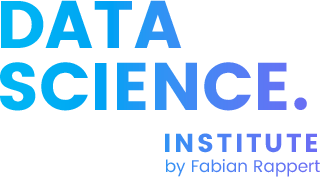

# Inhaltsverzeichnis 

- **Dunder-Funktionen**
    - **Beispiel: Punktklasse**
        - **Punkte erzeugen**
        - **Punkte anzeigen**
        - **Auf die Koordinaten zugreifen**
        - **Punkte addieren**
        - **Punkte vergleichen**
            - **Vergleichsmethoden: `__eq__`, `__ne__`, `__lt__`, `__le__`, `__gt__`, `__ge__`**
            - **Verwendung der Vergleichsmethoden**
        - **Die `__del__`-Methode (Destruktor)**
            - **Verwendung von `__del__`**



# Dunder-Funktionen


**Dunder-Funktionen** (kurz für "**D**ouble **Under**score" oder auch "Magic Methods") sind spezielle Methoden in Python, die mit zwei Unterstrichen beginnen und enden. Diese Methoden dienen dazu, das Verhalten von Objekten (Instanzen) zu definieren, wenn sie in bestimmten Kontexten verwendet werden.

Einige Beispiele für **Dunder-Funktionen** sind:

- `__init__(self, ...)`: Diese Funktion haben wir schon kennengelernt. Sie wird aufgerufen, wenn ein Objekt erstellt wird und dient der Initialisierung der Attribute des Objekts.

- `__str__(self)`: Diese Funktion gibt eine String-Repräsentation des Objekts zurück, die für Menschen lesbar ist. Diese Funktion muss einen String zurückliefern. Intern wird `__str__` aufgerufen, wenn die Instanz `i` einer Klasse "geprintet" wird, also bei `print(i)`.

- `__add__(self, other)`: Diese Funktion definiert das Verhalten des "+"-Operators für das Objekt mit einem anderen Objekt. Sie gibt das Ergebnis der Addition zurück.

- `__len__(self)`: Diese Funktion gibt die Anzahl der Elemente in einem Objekt zurück.

- `__getitem__(self, key)`: Diese Funktion gibt das Element zurück, das dem gegebenen Schlüssel entspricht. Wird aufgerufen, wenn die `[]`-Notation verwendet wird.

Dunder-Funktionen werden automatisch von Python aufgerufen, wenn bestimmte Operationen auf Objekten ausgeführt werden (z.B. Addition, Indexierung, String-Repräsentation). Durch das Implementieren von Dunder-Funktionen für eigenen Klassen, kann das Verhalten dieser Objekte in verschiedenen Kontexten definiert werden.

## Beispiel: Punktklasse

Wir wollen uns **Dunder-Funktionen** am Beispiel einer Klasse anschauen, die wir schon gesehen haben, der **Punkt**-Klasse. Diese Klasse repräsentiert einen Punkt in der 2-dimensionalen Ebene, hat daher 2 Koordinaten, `x` und `y`. Bei der Klassendefinition verwenden wir 6 Dunder-Funktionen um uns den späteren Umgang mit den Instanzen der Klasse im Code zu vereinfachen. 

- `__str__` um eine schöne Darstellung unseres Punktes anzeigen zu lassen, wenn er "geprintet" wird.
- `__add__(self, other)` um auf einfache Art und Weise zwei Punkte addieren zu können. Diese Funktion soll (in unserem Beispiel) einen neue Instanz von **Punkt** zurückliefern mit den neuen Koordinaten, wenn man zwei Instanzen addiert.
- `__getitem__` verwenden wir, damit wir auf die Koordinaten auch über die Namen `x` und `y` zugreifen können. 
- Wir verwenden `__lt__`, um zwei Punkte zu vergleichen.
- Mit `__del__` wird ein Punkt gelöscht.

In [ ]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __str__(self):
        return f"Punkt: \n x: {self.x}\n y: {self.y}"

    def __add__(self, other):
        new_point = Point(self.x + other.x, self.y + other.y)
        return new_point

    def __getitem__(self, key):
        if key == "x" or key == "X":
            return self.x
        if key == "y" or key == "Y":
            return self.y

    def __lt__(self, other):
        return (self.x**2 + self.y**2) ** (1 / 2) < (other.x**2 + other.y**2) ** (1 / 2)

    def __del__(self):
        print(f"Punkt({self.x},{self.y}) wird gelöscht.")

Die Klasse ist definiert, kommen wir zur Anwendung. Wir erzeugen als erstes einen Punkt $p_1$ mit den Koordinaten 
\begin{align}
p_1 = \left(\begin{array}{c} 1 \\ 2 \end{array}\right)
\end{align}
und einen Punkt $p_2$ mit den Koordinaten
\begin{align}
p_2 = \left(\begin{array}{c} 3 \\ 4 \end{array}\right)
\end{align}

### Punkte erzeugen

Beim erzeugen einer Instanz wird, wie schon gesehen, die Funktion `__init__` aufgerufen.

In [ ]:
p1 = Point(1, 2)
p2 = Point(3, 4)

### Punkte anzeigen

Als nächstes lassen wir unsere Punkte "printen", dadurch wird automatisch die `__str__`-Funktion aufgerufen:

In [ ]:
print(p1)  # Hier wird die Methode __str__ der Instanz p1 aufgerufen

In [ ]:
print(p2)  # Hier wird die Methode __str__ der Instanz p2 aufgerufen

### Auf die Koordinaten zugreifen

Nun wollen wir die Methode `__get_item__` testen. Dazu versuchen wir über die Notation `[]` auf die Werte zuzugreifen:

In [ ]:
p1["x"]

In [ ]:
p2["y"]

### Punkte addieren

Als letztes wollen wir die Methode `__add__` testen. Diese Funktion wird aufgerufen, wenn im Code eine Addition durch `+` ausgeführt wird. Neben der Instanz selber, erhält diese Funktion noch ein weiteres Argument `other`. So wie wir die Methode in diesem konkreten Fall implementiert haben, erhält die Funktion in diesem Fall eine weitere Instanz von **Punkt** und erzeugt in der Funktion eine neue Instanz der Klasse deren Koordinaten nach Addition der zwei Punkte entstehen. Wir führen also die mathematische Addition zweier Vektoren (Punkte) aus:

\begin{align}
p_1 + p_2 =\left(\begin{array}{c} 1 \\ 2 \end{array}\right) + \left(\begin{array}{c} 3 \\ 4 \end{array}\right) = \left(\begin{array}{c} 1 + 3 \\ 2 + 4  \end{array}\right) = \left(\begin{array}{c} 4 \\ 6 \end{array}\right) = p_3
\end{align}

Das Ergebnis dieser Operation speichern wir in einer neuen Variable $p_3$ und lassen uns danach das Ergebnis ausgeben:

In [ ]:
p3 = p1 + p2  # Ruft die Funktion __add__ der Instanz p1 auf mit p2 als Argument für other
print(p3)

Die gesamte obige Funktionalität hätten wir auch mit "klassischen" Methoden lösen können, z.B. eine Funktion `info(self)` zur Darstellung der Punkte oder eine Funktion `addiere(self, other)`. Dadurch hätten wir jedoch die Operationen nicht so schön lesbar wie oben aufschreiben können. Für die Addition von \(p1\) mit \(p2\) hätten wir in diesem Fall dann schreiben müssen

`p3 = p1.addiere(p2)`.

Dies wäre deutlich schwerer zu lesen! Man spricht hier auch davon, einen Operator zu "überladen". Wir können auch noch andere Operatoren überladen:

$$
\begin{array}{c|c|c} 
\text{Operator} & \text{Funktion} & \text{Beispiel} \\ \hline
\text{+} & \text{\_\_add\_\_} & p1 + p2 \\ \hline
\text{-} & \text{\_\_sub\_\_} & p1 - p2 \\ \hline
\text{*} & \text{\_\_mul\_\_} & p1 * p2 \\ \hline
\text{/} & \text{\_\_truediv\_\_} & p1 / p2 \\ 
\end{array}
$$

Dadurch können wir mathematische Operationen auf "unseren" Datentypen definieren. So könnten wir in obigen Beispiel noch definieren, was passieren soll, wenn ein Punkt mit einer Zahl multipliziert wird. Dafür müssen wir nur die Funktion `\_\_mul\_\_` in der Klasse schreiben (_überladen_).


### Punkte vergleichen

#### Vergleichsmethoden: `__eq__`, `__ne__`, `__lt__`, `__le__`, `__gt__`, `__ge__`

In Python können wir benutzerdefinierte Vergleichsoperationen für Ihre eigenen Klassen implementieren, indem wir spezielle Methoden wie `__eq__` (Gleichheit), `__ne__` (Ungleichheit), `__lt__` (kleiner als), `__le__` (kleiner oder gleich), `__gt__` (größer als), und `__ge__` (größer oder gleich) definieren. 

Diese Methoden werden automatisch aufgerufen, wenn Vergleichsoperatoren (`==`, `!=`, `<`, `<=`, `>`, `>=`) zwischen den Instanzen Ihrer Klasse verwendet werden. Das gibt Ihnen die Freiheit, benutzerdefinierte Regeln für den Vergleich Ihrer Objekte zu implementieren. Übrigens, es gibt auch ähnliche Variablen für `__len__` etc.

#### Verwendung der Vergleichsmethoden

Jede dieser Methoden nimmt ein Argument: `other`, das das Objekt ist, mit dem das aktuelle Objekt verglichen wird. Die Methoden sollten einen booleschen Wert (`True` oder `False`) zurückgeben.

**Beispiel**: Wenn wir eine Klasse Punkt haben, können wir die Methode `__lt__` verwenden, um zu definieren, wie zwei Punkte auf der Basis ihres Abstands vom Ursprung verglichen werden können:

\begin{align}
 \sqrt{1^2 + 2^2} < \sqrt{3^2 + 4^2} \Longrightarrow  p_1 < p_2
\end{align}

**Achtung**: Wenn wir spezielle Methoden wie `__eq__`, `__ne__`, `__lt__`, etc. implementieren, stellen wir sicher, dass sie konsistent sind. Das heißt, wenn `a == b` `True` ist, sollte `a != b` `False` sein.

In [ ]:
p1 < p2  # True

### Die `__del__`-Methode (Destruktor)

Die `__del__`-Methode in Python fungiert als Destruktor für eine Klasse. Sie wird aufgerufen, sobald ein Objekt der Klasse nicht mehr benötigt wird, das heißt, wenn alle Referenzen auf das Objekt entfernt wurden. Dies bietet eine Möglichkeit, Ressourcen freizugeben oder abschließende Operationen durchzuführen, bevor das Objekt gelöscht wird.

#### Verwendung von `__del__`

Die `__del__`-Methode erfordert keine Argumente und wird automatisch aufgerufen, wenn das Objekt gelöscht wird. 

**Achtung:** Obwohl die `__del__`-Methode eine praktische Möglichkeit zur Durchführung von Aufräumarbeiten bietet, ist sie nicht eine Garantie dafür, dass sie immer und sofort aufgerufen wird, da sie vom Python-Garbage-Collector abhängig ist. Es ist oft besser, explizite Methoden zur Freigabe von Ressourcen zu verwenden.

In [ ]:
del p1  # Point(1,2)
print(p1)